In [1]:
import torch
from utils import solve_riccati
import numpy as np
from network import PhiNetwork, ScoreNetwork
from utils import batched_jacobian
import matplotlib.pyplot as plt

In [2]:
phi_tr = ScoreNetwork(input_dim=2+1, out_dim=2, hidden_dim=32)
phi_tr.load_state_dict(torch.load('network/tr_phi_network_ip_bsde_nl0.5.pth'))
phi_adjoint = ScoreNetwork(input_dim=2+1, out_dim=2, hidden_dim=32)
phi_adjoint.load_state_dict(torch.load('network/ad_phi_network_ip_bsde_nl0.5.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_49935/1348482887.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  phi_tr.load_state_dict(torch.load('network/tr

<All keys matched successfully>

In [3]:
T = 4.0  # End time
n = 2    # Dimension of state space
m = 1    # Dimension of Brownian motion
N = 10000 # Number of training samples
dt = 0.05
steps = int(T/dt)
noise_level = 0.5

In [4]:
def f(x, t, ut=None):
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    df1 = x[:, 1]
    df2 = torch.sin(x[:, 0]) - 0.01 * x[:, 1]
    df = torch.stack((df1, df2), dim=1)
    return df


def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[0.0], [1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def lf(x):
    """
    Terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Terminal cost. Shape (N,)
    """
    # Q_f = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
    # return 0.5 * ((x @ Q_f) * x).sum(dim=1)
    return 0.5 * x[:,1] * x[:,1] + 1 - torch.cos(x[:,0])

In [5]:
from utils import rollout

iteration    0 | autograd loss 24678.8 | phi loss 24678.8
iteration  500 | autograd loss 20346.4 | phi loss 19352.1
iteration 1000 | autograd loss 19275.8 | phi loss 17562.2
iteration 1500 | autograd loss 18146.4 | phi loss 16125.5
iteration 2000 | autograd loss 17885 | phi loss 15686.5
iteration 2500 | autograd loss 17352.3 | phi loss 15185.1
iteration 3000 | autograd loss 17299.1 | phi loss 15098.6
iteration 3500 | autograd loss 16727 | phi loss 14758.2
iteration 4000 | autograd loss 17161 | phi loss 14946.1
iteration 4500 | autograd loss 17077 | phi loss 14924.8
iteration 5000 | autograd loss 17057.4 | phi loss 14899.8
iteration 5500 | autograd loss 17131.8 | phi loss 14830
iteration 6000 | autograd loss 16965.2 | phi loss 14803.2
iteration 6500 | autograd loss 17202 | phi loss 14959.8
iteration 7000 | autograd loss 17240.8 | phi loss 14951.4
iteration 7500 | autograd loss 17116.7 | phi loss 14812.8
iteration 8000 | autograd loss 17404.3 | phi loss 15014.3
iteration 8500 | autograd 

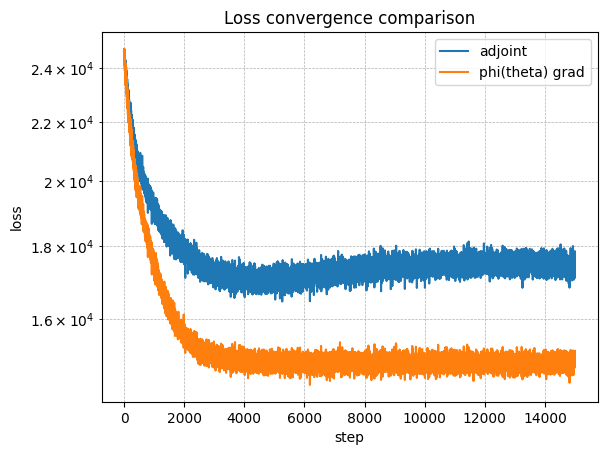

In [7]:
theta0 = torch.randn((N, n))

theta_ad = theta0.clone().detach().requires_grad_(True)
theta_phi  = theta0.clone().detach().requires_grad_(True)  # requires_grad can stay True; we won't call backward()

opt_ad = torch.optim.Adam([theta_ad], lr=1e-3)
opt_phi  = torch.optim.Adam([theta_phi],  lr=1e-3)

loss_hist_ad = []
loss_hist_phi  = []
theta_hist_ad = []
theta_hist_phi  = []
theta_hist_ad.append(theta_ad.detach().clone())
theta_hist_phi.append(theta_phi.detach().clone())
for i in range(15000):
    W_f = torch.randn((steps+1, N, m)) * np.sqrt(dt)
    # ======== Method A: autograd ========
    opt_ad.zero_grad(set_to_none=True)

    
    with torch.no_grad():
        xT_ad = rollout(f, g, T, dt, theta_ad, W_f)[-1]
        loss_ad = lf(xT_ad).sum(dim=0)


    with torch.no_grad():
        gad = phi_adjoint(theta_ad, torch.tensor(0.0).repeat(theta_ad.shape[0], 1)).detach()  # shape (N, n)
        theta_ad.grad = gad.detach()
    opt_ad.step()

    # ======== Method B: custom phi gradient ========
    opt_phi.zero_grad(set_to_none=True)

    # compute loss for logging only (optional but useful)
    # If rollout is expensive and you only care about update, you can skip this forward.
    with torch.no_grad():
        xT_phi = rollout(f, g, T, dt, theta_phi, W_f)[-1]
        loss_phi = lf(xT_phi).sum(dim=0)

    # apply your gradient estimator
    # IMPORTANT: optimizer expects theta_phi.grad to be a tensor on same device/dtype
    with torch.no_grad():
        ghat = phi_tr(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1))  # shape (N, n)
        theta_phi.grad = ghat.detach()
    opt_phi.step()

    # ---- log ----
    loss_hist_ad.append(loss_ad.detach().item() if loss_ad.numel()==1 else loss_ad.detach().sum().item())
    loss_hist_phi.append(loss_phi.detach().item()  if loss_phi.numel()==1  else loss_phi.detach().sum().item())

    theta_hist_ad.append(theta_ad.detach().clone())
    theta_hist_phi.append(theta_phi.detach().clone())

    # optional: print occasionally
    if i % max(1, 500) == 0:
        print(f"iteration {i:4d} | autograd loss {loss_hist_ad[-1]:.6g} | phi loss {loss_hist_phi[-1]:.6g}")

# ---- final report ----
print("\nFinal:")
print(f"autograd: loss={loss_hist_ad[-1]:.6g}")
print(f"phi     : loss={loss_hist_phi[-1]:.6g}")

# ---- plot ----
plt.figure()
plt.plot(loss_hist_ad, label="adjoint")
plt.plot(loss_hist_phi,  label="phi(theta) grad")
plt.yscale("log")  # often helpful; remove if you prefer linear
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Loss convergence comparison")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

Text(0.5, 1.0, 'Optimal theta comparison')

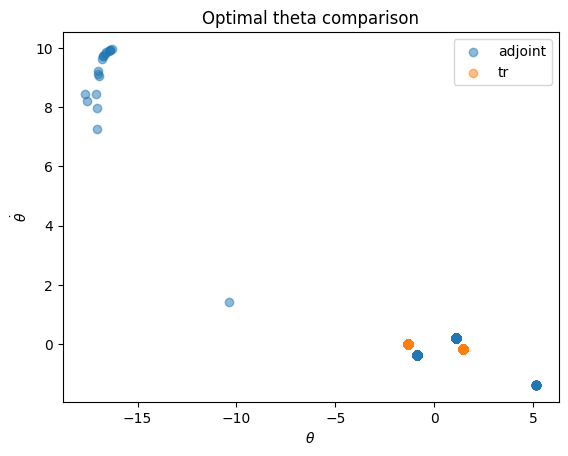

In [9]:
## plot of optimal theta
plt.figure()
plt.scatter(theta_ad.detach().numpy()[:,0], theta_ad.detach().numpy()[:,1], label="adjoint", alpha=0.5)
plt.scatter(theta_phi.detach().numpy()[:,0], theta_phi.detach().numpy()[:,1], label="tr", alpha=0.5)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\dot{\theta}$")
plt.legend()
plt.title("Optimal theta comparison")

In [10]:
torch.save(theta_ad, 'data/theta_ad_final.pth')
torch.save(theta_phi, 'data/theta_tr_final.pth')